This notebook contains some examples of figures created by the code in this repository.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import datetime
import scipy

## Plot gold daily returns

In [ ]:
from stock_price_returns import download_financial_data, calculate_log_daily_returns, plot_daily_returns_hist

In [ ]:
ticker = 'GC=F'

start_date = datetime.datetime(2019, 1, 1)
end_date = datetime.datetime(2026, 1, 1)

closing_prices = download_financial_data(ticker, start_date, end_date)

In [ ]:
closing_prices.describe()

,GC=F
count,1762.000000
mean,2077.816059
std,658.885381
min,1269.300049
25%,1730.149994
50%,1869.949951
75%,2281.850037
max,4529.100098


In [ ]:
log_daily_returns = calculate_log_daily_returns(closing_prices)
log_daily_returns.describe()

,GC=F
count,1761.000000
mean,0.000691
std,0.010330
min,-0.059062
25%,-0.004171
50%,0.000944
75%,0.006305
max,0.057775


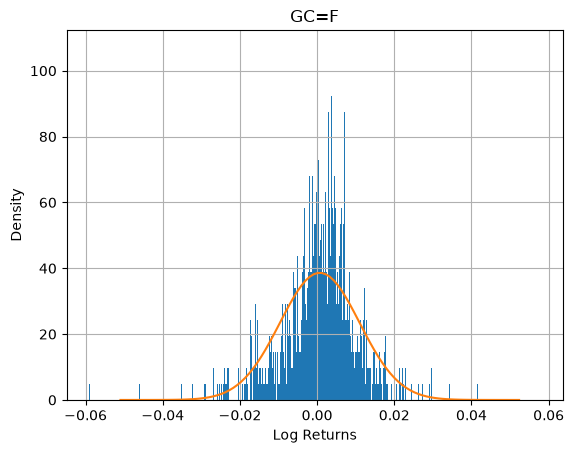

In [ ]:
plot_daily_returns_hist(ticker, log_daily_returns)

## Portfolio optimisation

In [2]:
import markowitz_model as mm

In [3]:
n_trading_days = 252    # trading days in a year
n_portfolios = 250    # number of random portfolios to generate

assets = ['AAPL', 'WMT', 'TSLA', 'GE', 'AMZN', 'GC=F']  # asset universe
start_date = datetime.date(2019, 1, 1)
end_date = datetime.date.today()
risk_free_rate = 0.02

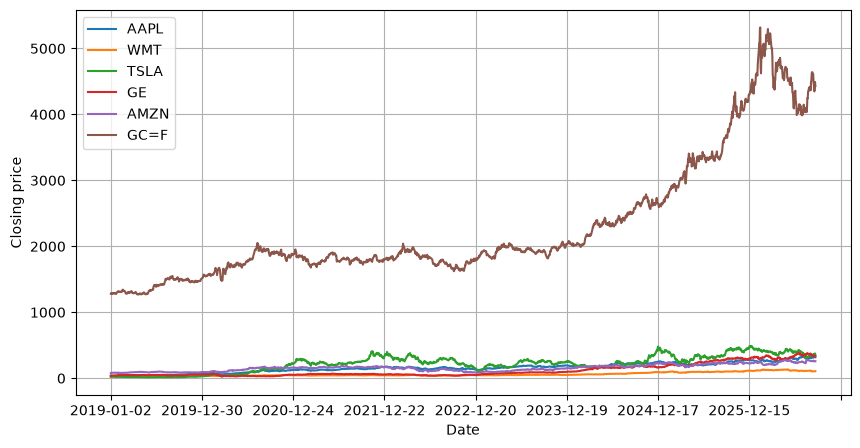

In [4]:
#dataset = mm.download_data(assets, start_date, end_date)
#dataset.to_csv("testing_dataset.csv")
dataset = pd.read_csv("testing_dataset.csv", index_col=0)
mm.show_data(dataset, 'Date', 'Closing price')

In [5]:
log_daily_returns = mm.calculate_returns(dataset)
mm.show_statistics(log_daily_returns, n_trading_days)

Mean annual returns
AAPL    0.29
WMT     0.17
TSLA    0.38
GE      0.29
AMZN    0.16
GC=F    0.16
dtype: float64
Covariance matrix
      AAPL   WMT  TSLA    GE  AMZN  GC=F
AAPL  0.09  0.02  0.09  0.04  0.06  0.00
WMT   0.02  0.05  0.02  0.01  0.02  0.00
TSLA  0.09  0.02  0.40  0.06  0.09  0.01
GE    0.04  0.01  0.06  0.15  0.04  0.00
AMZN  0.06  0.02  0.09  0.04  0.12  0.00
GC=F  0.00  0.00  0.01  0.00  0.00  0.03


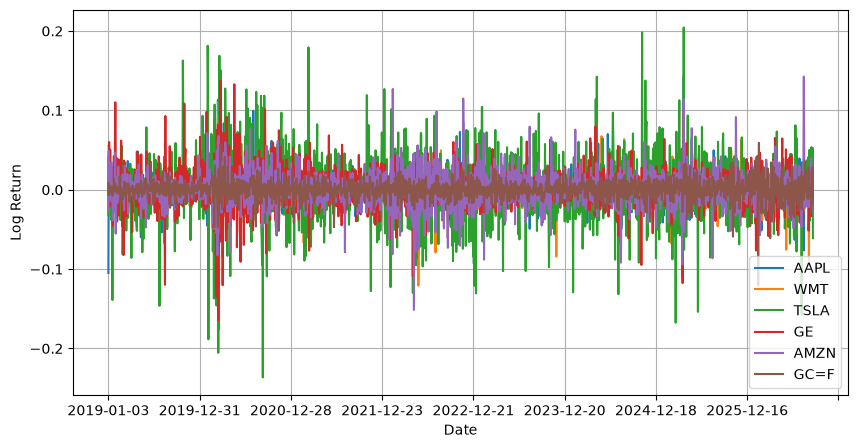

In [6]:
mm.show_data(log_daily_returns, 'Date', 'Log Return')

Expected return and volatility with an **equal-weighted** portfolio

In [7]:
weights = np.ones(len(assets)) / len(assets)
mm.statistics(weights, log_daily_returns, n_trading_days, risk_free_rate=0.03)

array([0.24165621, 0.22285595, 0.94974447])

Generate random portfolios and plot risk-return and Sharpe ratio:

\begin{equation}
\mu = 
\end{equation}

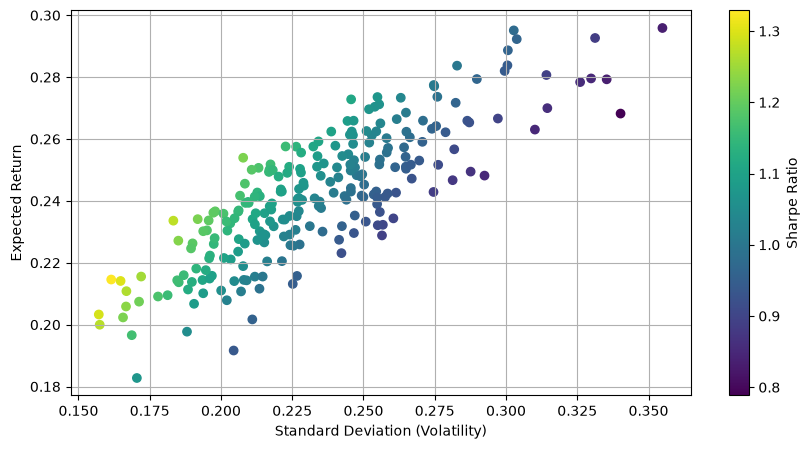

In [8]:
pweights, means, risks = mm.generate_portfolios(assets, log_daily_returns, n_portfolios, n_trading_days)
mm.show_portfolios(means, risks)

Find the tangency portfolio (i.e. the portfolio with the highest Sharpe ratio)

Optimal portfolio:  [0.193 0.196 0.025 0.128 0.    0.459]
Expected return, volatility and Sharpe ratio:  [0.21  0.15  1.266]


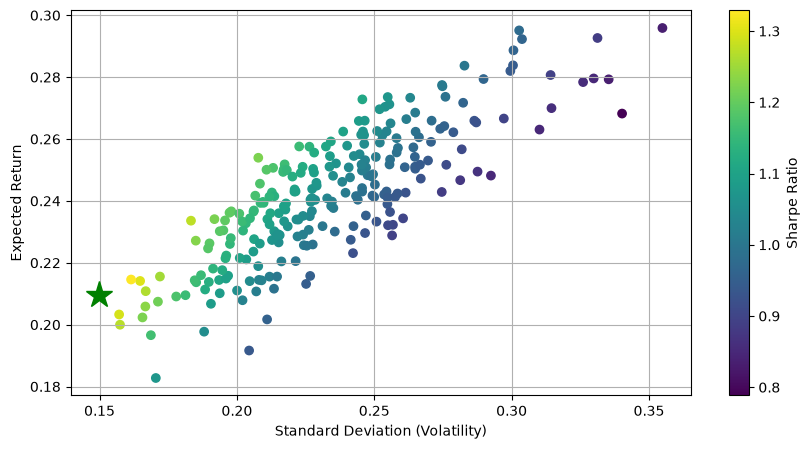

In [9]:
optimum  = mm.optimize_portfolio(assets, pweights, log_daily_returns, n_trading_days)
mm.print_optimal_portfolio(optimum, log_daily_returns, n_trading_days, risk_free_rate)
mm.show_optimal_portfolio(optimum, log_daily_returns, means, risks, n_trading_days, risk_free_rate)